# 05. Multi-resolution analysis of the gridded BayesNF dataset

How does the BayesNF gridded product change as the spatial resolution
goes from 1 km to 10 km? Three analyses on March 2023 — the one month
predicted at every resolution.

1. **Out-of-sample station comparison.** Pull the prediction in the
   cell that contains each holdout station, compute per-resolution MAE
   and a quantile-based CRPS.
2. **Spatial variability / roughness.** Local gradient magnitude of the
   predicted mean field, computed on the native grid of each resolution
   and aggregated over the month.
3. **Self-consistency.** Average the 1 km field into each coarse grid
   cell and compare to the direct prediction at that resolution.

Each section writes figures to ``results/dataset/figures/`` and a row
to a summary table at ``results/dataset/multires/summary.csv``.


## 1. Setup


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3

ROOT = Path('../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

S3_BUCKET    = 'thesis-data-ismaktam'
RESOLUTIONS  = [1, 2, 5, 10]    # km
MONTH_KEY    = '2023-03'
PRECIP_SCALE = 10               # rainfall_int = rainfall_mm * 10

FIG_DIR = Path('results/dataset/figures')
OUT_DIR = Path('results/dataset/multires')
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

s3 = boto3.client('s3')
print(f'cwd        : {os.getcwd()}')
print(f'resolutions: {RESOLUTIONS} km')
print(f'month      : {MONTH_KEY}')


cwd        : /Users/etomengoi/Desktop/precip_interpolation_thesis
resolutions: [1, 2, 5, 10] km
month      : 2023-03


## 2. Load predictions and holdout stations

Predictions live at ``s3://thesis-data-ismaktam/dataset/predictions_{r}km/2023-03.parquet``
and are cached locally on first use. The holdout test set (fold = -1)
is the never-trained station pool used in Chapter 6 to evaluate the
final model. Both are restricted to March 2023.


In [2]:
def _cached(local: Path, key: str) -> Path:
    local.parent.mkdir(parents=True, exist_ok=True)
    if not local.exists():
        s3.download_file(S3_BUCKET, key, str(local))
    return local


# Predictions at the four resolutions.
preds = {}
for r in RESOLUTIONS:
    p = _cached(Path(f'results/dataset/predictions_{r}km/{MONTH_KEY}.parquet'),
                f'dataset/predictions_{r}km/{MONTH_KEY}.parquet')
    df = pd.read_parquet(p)
    df['datetime'] = pd.to_datetime(df['datetime'])
    preds[r] = df
    print(f'  {r:>2} km : {len(df):>10,} rows, '
          f'{df["cell_id"].nunique():>8,} cells, '
          f'{df["datetime"].nunique():>3} days')

# Holdout stations for March 2023.
holdout_path = _cached(Path('results/dataset/bayesnf_holdout_test.parquet'),
                        'bayesnf/data/bayesnf_holdout_test.parquet')
stn = pd.read_parquet(
    holdout_path,
    columns=['datetime', 'station_id', 'latitude', 'longitude',
             'x_proj', 'y_proj', 'rainfall', 'rainfall_int'],
    filters=[('datetime', '>=', pd.Timestamp(f'{MONTH_KEY}-01')),
             ('datetime', '<=', pd.Timestamp(f'{MONTH_KEY}-31'))],
)
stn['datetime'] = pd.to_datetime(stn['datetime'])
print(f'\nholdout stations: {stn["station_id"].nunique()}  '
      f'({len(stn):,} station-days)')


   1 km :  6,287,358 rows,  202,818 cells,  31 days
   2 km :  1,575,420 rows,   50,820 cells,  31 days
   5 km :    253,704 rows,    8,184 cells,  31 days
  10 km :     64,108 rows,    2,068 cells,  31 days

holdout stations: 492  (15,252 station-days)


## 3. Out-of-sample station comparison

For each resolution we snap every holdout station onto the prediction
grid by rounding its projected coordinate to the nearest coarse-cell
centre. The MAE is computed against the held-out daily observation;
the CRPS is approximated from the eleven predicted quantiles using
the average quantile-score representation

$$\text{CRPS}(F, y) \approx \frac{2}{K} \sum_{k=1}^K \big(y - q_{\tau_k}\big)
\big(\tau_k - \mathbf{1}\{y < q_{\tau_k}\}\big),$$

which is the standard discretisation when the predictive distribution
is supplied as a set of equally spaced quantiles.


In [3]:
Q_LEVELS = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
                     0.60, 0.70, 0.80, 0.90, 0.95])
Q_COLS   = [f'q{int(q*100):02d}' for q in Q_LEVELS]


def grid_origin_step(df: pd.DataFrame) -> tuple[float, float, float, float]:
    xs = np.sort(df['x_proj'].unique())
    ys = np.sort(df['y_proj'].unique())
    return xs.min(), ys.min(), float(np.diff(xs)[0]), float(np.diff(ys)[0])


def snap_to_grid(stn_df: pd.DataFrame, grid_df: pd.DataFrame) -> pd.DataFrame:
    """Add `cell_x`, `cell_y` columns to `stn_df`: snapped projected
    coordinates of the grid cell that contains each station."""
    x0, y0, dx, dy = grid_origin_step(grid_df)
    out = stn_df.copy()
    out['cell_x'] = (np.round((stn_df['x_proj'].to_numpy() - x0) / dx)
                     * dx + x0).round(1)
    out['cell_y'] = (np.round((stn_df['y_proj'].to_numpy() - y0) / dy)
                     * dy + y0).round(1)
    return out


def quantile_crps(q_vals: np.ndarray, y: np.ndarray,
                  q_levels: np.ndarray = Q_LEVELS) -> np.ndarray:
    """Per-row CRPS approximated from `q_vals` (n_rows, n_q) and y (n_rows,)."""
    y_col = y[:, None]
    indic = (y_col < q_vals).astype(np.float64)
    pinball = (y_col - q_vals) * (q_levels[None, :] - indic)
    return 2.0 * pinball.mean(axis=1)


rows = []
station_results = {}
for r in RESOLUTIONS:
    grid_df = preds[r]
    pred_keyed = grid_df.copy()
    pred_keyed['cell_x'] = pred_keyed['x_proj'].round(1)
    pred_keyed['cell_y'] = pred_keyed['y_proj'].round(1)

    snapped = snap_to_grid(stn, grid_df)
    merged = snapped.merge(
        pred_keyed[['datetime', 'cell_x', 'cell_y', 'mean_mm'] + Q_COLS],
        on=['datetime', 'cell_x', 'cell_y'], how='inner',
    )

    y = merged['rainfall'].to_numpy()
    yhat = merged['mean_mm'].to_numpy()
    q = merged[Q_COLS].to_numpy()
    mae = float(np.mean(np.abs(y - yhat)))
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    crps = float(np.mean(quantile_crps(q, y)))

    rows.append({'resolution_km': r, 'n_pairs': len(merged),
                 'MAE': mae, 'RMSE': rmse, 'CRPS': crps})
    station_results[r] = merged
    print(f'  {r:>2} km : n={len(merged):>6,}  '
          f'MAE={mae:.3f}  RMSE={rmse:.3f}  CRPS={crps:.3f} mm')

station_summary = pd.DataFrame(rows).set_index('resolution_km')
station_summary.to_csv(OUT_DIR / 'station_metrics.csv')
station_summary


   1 km : n=15,252  MAE=0.294  RMSE=0.616  CRPS=0.275 mm
   2 km : n=15,252  MAE=0.299  RMSE=0.629  CRPS=0.277 mm
   5 km : n=15,159  MAE=0.322  RMSE=1.089  CRPS=0.281 mm
  10 km : n=15,097  MAE=0.338  RMSE=0.710  CRPS=0.293 mm


,n_pairs,MAE,RMSE,CRPS
resolution_km,,,,
1,15252,0.294425,0.616489,0.274796
2,15252,0.299425,0.628686,0.276611
5,15159,0.322010,1.088887,0.281299
10,15097,0.337650,0.710137,0.292731


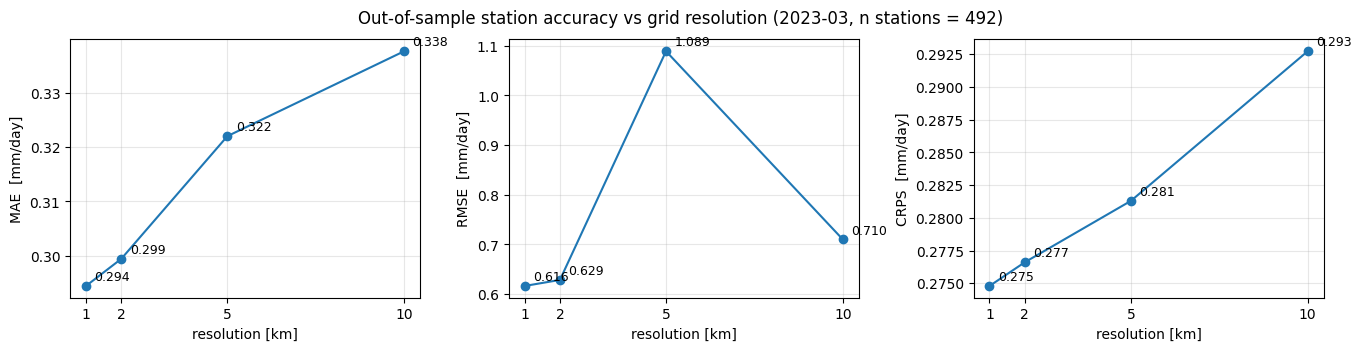

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4), constrained_layout=True)
metric_labels = [('MAE', 'MAE  [mm/day]'),
                 ('RMSE', 'RMSE  [mm/day]'),
                 ('CRPS', 'CRPS  [mm/day]')]
for ax, (col, lbl) in zip(axes, metric_labels):
    ax.plot(station_summary.index, station_summary[col],
            marker='o', color='tab:blue')
    for r in station_summary.index:
        ax.annotate(f'{station_summary.loc[r, col]:.3f}',
                    (r, station_summary.loc[r, col]),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)
    ax.set_xlabel('resolution [km]')
    ax.set_ylabel(lbl)
    ax.set_xticks(station_summary.index)
    ax.grid(alpha=0.3)
fig.suptitle(f'Out-of-sample station accuracy vs grid resolution '
             f'({MONTH_KEY}, n stations = {stn["station_id"].nunique()})')
plt.savefig(FIG_DIR / 'multires_station_metrics.png', dpi=150)
plt.show()


## 4. Spatial variability and roughness

For every (day, resolution) we rasterise the mean field onto its native
grid (the cells are exactly regular in EPSG:3035), compute the local
gradient magnitude

$$|\nabla \hat{\mu}|_{ij} = \sqrt{(\partial_x \hat{\mu})^2 + (\partial_y \hat{\mu})^2}$$

with second-order central differences (``np.gradient``), and report two
summaries: the **mean** of $|\nabla\hat{\mu}|$ over all wet cells of
the month (overall smoothness budget), and its **95th percentile**
(strength of the sharpest features, e.g. orographic edges).


In [5]:
def rasterise(df_day: pd.DataFrame, x0: float, y0: float,
              dx: float, dy: float, nx: int, ny: int,
              column: str = 'mean_mm') -> np.ndarray:
    arr = np.full((ny, nx), np.nan, dtype=np.float64)
    ix = np.round((df_day['x_proj'].to_numpy() - x0) / dx).astype(int)
    iy = np.round((df_day['y_proj'].to_numpy() - y0) / dy).astype(int)
    arr[iy, ix] = df_day[column].to_numpy()
    return arr


def gradient_magnitude_per_km(arr: np.ndarray, dx_m: float,
                              dy_m: float) -> np.ndarray:
    """|grad mean| in mm per kilometre, NaN-safe via simple fill."""
    filled = np.where(np.isnan(arr), 0.0, arr)
    gy, gx = np.gradient(filled, dy_m / 1000.0, dx_m / 1000.0)
    g = np.sqrt(gx ** 2 + gy ** 2)
    mask = np.isnan(arr)
    g[mask] = np.nan
    return g


rough_rows = []
last_day_grad = {}   # cached for the multi-panel map below
for r in RESOLUTIONS:
    grid_df = preds[r]
    x0, y0, dx, dy = grid_origin_step(grid_df)
    xs = np.sort(grid_df['x_proj'].unique())
    ys = np.sort(grid_df['y_proj'].unique())
    nx, ny = len(xs), len(ys)

    grads_mean, grads_p95, vars_field = [], [], []
    for day, df_day in grid_df.groupby('datetime'):
        arr = rasterise(df_day, x0, y0, dx, dy, nx, ny, column='mean_mm')
        g = gradient_magnitude_per_km(arr, dx, dy)
        grads_mean.append(float(np.nanmean(g)))
        grads_p95.append(float(np.nanpercentile(g, 95)))
        vars_field.append(float(np.nanvar(arr)))
        last_day_grad[r] = (arr, g, (x0, y0, dx, dy, nx, ny))

    rough_rows.append({
        'resolution_km': r,
        'mean_grad_mm_per_km': float(np.mean(grads_mean)),
        'p95_grad_mm_per_km':  float(np.mean(grads_p95)),
        'mean_field_variance': float(np.mean(vars_field)),
    })
    print(f'  {r:>2} km : <|grad|>={np.mean(grads_mean):.3f}  '
          f'p95|grad|={np.mean(grads_p95):.3f}  '
          f'var(field)={np.mean(vars_field):.2f}')

rough_summary = pd.DataFrame(rough_rows).set_index('resolution_km')
rough_summary.to_csv(OUT_DIR / 'roughness_metrics.csv')
rough_summary


   1 km : <|grad|>=0.146  p95|grad|=0.266  var(field)=13.20
   2 km : <|grad|>=0.101  p95|grad|=0.215  var(field)=13.44
   5 km : <|grad|>=0.067  p95|grad|=0.164  var(field)=14.05
  10 km : <|grad|>=0.045  p95|grad|=0.129  var(field)=8.88


,mean_grad_mm_per_km,p95_grad_mm_per_km,mean_field_variance
resolution_km,,,
1,0.145782,0.265565,13.201784
2,0.100908,0.215128,13.438549
5,0.066980,0.163954,14.049446
10,0.044537,0.129219,8.883009


case-study day  : 2023-03-26
  selected from 27 days with dry pixels (min<0.1)
  spatial std at 1 km on this day: 6.31 mm/day
shared colour range : [0.40, 17.97] mm/day (vmax = p99 of wet cells; absolute max = 250.00)


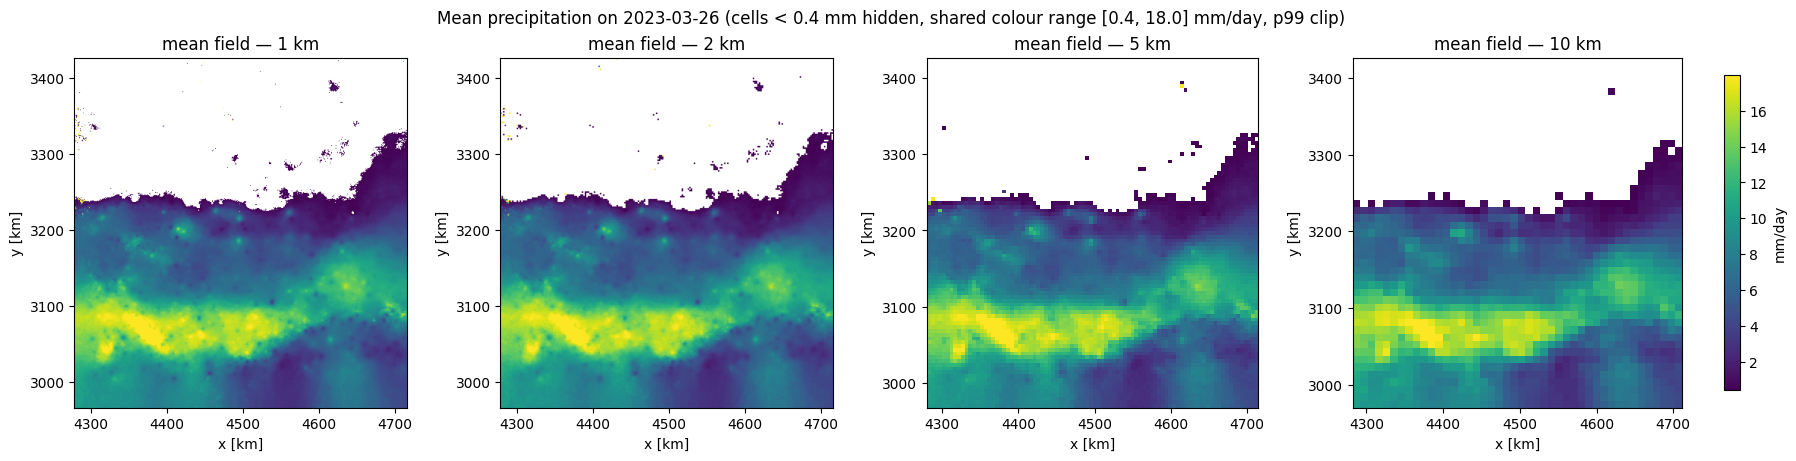

In [6]:
WET_THRESHOLD = 0.4   # mm/day; cells below this stay white on the map

# Pick a case-study day that *contrasts* the four resolutions: needs
# both truly dry cells (min ~ 0) and a sharp wet feature. Selecting by
# total rainfall picks frontal systems that wet the whole domain
# uniformly — coarse and fine look identical there. Instead, restrict
# to days whose 1 km field includes dry pixels (min < 0.1) and pick the
# largest spatial standard deviation.
_day_stats = (preds[1]
              .groupby('datetime')['mean_mm']
              .agg(min='min', std='std')
              .reset_index())
_dry_days = _day_stats[_day_stats['min'] < 0.1]
CASE_DATE = (_dry_days.sort_values('std', ascending=False)
                       .iloc[0]['datetime'])
print(f'case-study day  : {CASE_DATE.date()}')
print(f'  selected from {len(_dry_days)} days with dry pixels (min<0.1)')
print(f'  spatial std at 1 km on this day: '
      f'{_dry_days.set_index("datetime").loc[CASE_DATE, "std"]:.2f} mm/day')

# Rasterise the mean field for the case day at every resolution; cells
# below `WET_THRESHOLD` are set to NaN so they render as white. A
# common (vmin, vmax) over all four resolutions makes the colour bar
# directly comparable across panels.
case_arrays = {}
for r in RESOLUTIONS:
    grid_df = preds[r]
    x0, y0, dx, dy = grid_origin_step(grid_df)
    xs = np.sort(grid_df['x_proj'].unique())
    ys = np.sort(grid_df['y_proj'].unique())
    nx, ny = len(xs), len(ys)
    day = grid_df[grid_df['datetime'] == CASE_DATE]
    arr = rasterise(day, x0, y0, dx, dy, nx, ny, column='mean_mm')
    arr_masked = np.where(arr < WET_THRESHOLD, np.nan, arr)
    case_arrays[r] = (arr_masked, xs, ys)

wet_vals = np.concatenate([
    a[~np.isnan(a)].ravel() for (a, _, _) in case_arrays.values()
])
# Clip vmax to the 99th percentile of wet values: one or two extreme
# cells on the 1 km grid otherwise compress the bulk of the colour bar
# into a narrow band and the resolution panels become indistinguishable.
vmin_g = float(wet_vals.min())
vmax_g = float(np.percentile(wet_vals, 99))
print(f'shared colour range : [{vmin_g:.2f}, {vmax_g:.2f}] mm/day '
      f'(vmax = p99 of wet cells; absolute max = {wet_vals.max():.2f})')

cmap = plt.cm.viridis.copy()
cmap.set_bad('white')

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
last_im = None
for ax, r in zip(axes, RESOLUTIONS):
    arr, xs, ys = case_arrays[r]
    im = ax.imshow(arr, origin='lower', cmap=cmap,
                   vmin=vmin_g, vmax=vmax_g,
                   extent=(xs.min()/1000, xs.max()/1000,
                           ys.min()/1000, ys.max()/1000))
    ax.set_title(f'mean field — {r} km')
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
    last_im = im

fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9,
             label='mm/day', pad=0.02)
fig.suptitle(f'Mean precipitation on {CASE_DATE.date()} '
             f'(cells < {WET_THRESHOLD} mm hidden, shared colour range '
             f'[{vmin_g:.1f}, {vmax_g:.1f}] mm/day, p99 clip)')
plt.savefig(FIG_DIR / 'multires_case_day.png', dpi=150)
plt.show()


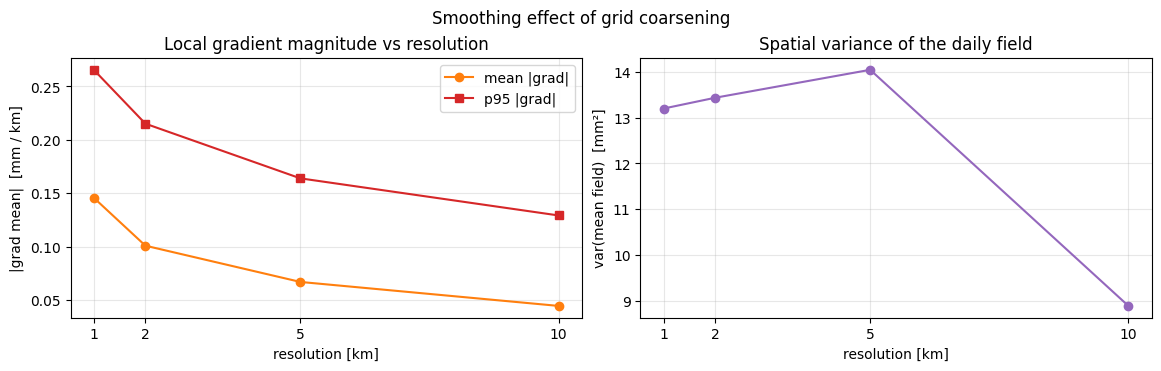

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), constrained_layout=True)
ax = axes[0]
ax.plot(rough_summary.index, rough_summary['mean_grad_mm_per_km'],
        marker='o', color='tab:orange', label='mean |grad|')
ax.plot(rough_summary.index, rough_summary['p95_grad_mm_per_km'],
        marker='s', color='tab:red', label='p95 |grad|')
ax.set_xlabel('resolution [km]')
ax.set_ylabel('|grad mean|  [mm / km]')
ax.set_xticks(rough_summary.index)
ax.set_title('Local gradient magnitude vs resolution')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rough_summary.index, rough_summary['mean_field_variance'],
        marker='o', color='tab:purple')
ax.set_xlabel('resolution [km]')
ax.set_ylabel('var(mean field)  [mm²]')
ax.set_xticks(rough_summary.index)
ax.set_title('Spatial variance of the daily field')
ax.grid(alpha=0.3)
fig.suptitle('Smoothing effect of grid coarsening')
plt.savefig(FIG_DIR / 'multires_roughness.png', dpi=150)
plt.show()


## 5. Self-consistency: 1 km aggregated vs direct coarse prediction

Take the 1 km mean field and average all fine cells whose centre falls
into a given coarse cell (a clean $k \times k$ block average because
the coarse grids are concentric multiples of the 1 km grid). Compare
the aggregated field to the direct coarse prediction at 2, 5 and
10 km — cell-by-cell, day-by-day, over March 2023.

If the two fields agree, the model is **resolution-coherent**: the
coarse prediction is essentially the spatial average of the fine
prediction. Disagreement of a few tenths of a mm is expected from the
non-linear $\textsf{ZINB}$ likelihood; a systematic bias would be a
real finding about the dataset.


In [8]:
def aggregate_to_coarse(fine_df: pd.DataFrame,
                        coarse_grid: pd.DataFrame,
                        column: str = 'mean_mm') -> pd.DataFrame:
    """Average `column` from the 1 km field onto the coarse grid by
    rounding every fine-cell centre to its enclosing coarse-cell
    centre. Returns a DataFrame keyed by (datetime, coarse_x, coarse_y).
    """
    x0c, y0c, dxc, dyc = grid_origin_step(coarse_grid)
    fine = fine_df[['datetime', 'x_proj', 'y_proj', column]].copy()
    fine['cell_x'] = (np.round((fine['x_proj'].to_numpy() - x0c) / dxc)
                      * dxc + x0c).round(1)
    fine['cell_y'] = (np.round((fine['y_proj'].to_numpy() - y0c) / dyc)
                      * dyc + y0c).round(1)
    return (fine.groupby(['datetime', 'cell_x', 'cell_y'],
                         as_index=False)[column]
                 .mean())


fine = preds[1]
consistency_rows = []
diff_fields = {}
for r in [2, 5, 10]:
    coarse_grid = preds[r]
    agg = aggregate_to_coarse(fine, coarse_grid, column='mean_mm')
    agg = agg.rename(columns={'mean_mm': 'mean_from_1km'})

    direct = coarse_grid[['datetime', 'x_proj', 'y_proj', 'mean_mm']].copy()
    direct['cell_x'] = direct['x_proj'].round(1)
    direct['cell_y'] = direct['y_proj'].round(1)
    direct = direct.rename(columns={'mean_mm': 'mean_direct'})

    merged = direct.merge(agg, on=['datetime', 'cell_x', 'cell_y'], how='inner')
    delta = merged['mean_direct'].to_numpy() - merged['mean_from_1km'].to_numpy()
    consistency_rows.append({
        'resolution_km': r,
        'n_pairs': len(merged),
        'bias_direct_minus_agg': float(np.mean(delta)),
        'MAE_direct_vs_agg': float(np.mean(np.abs(delta))),
        'RMSE_direct_vs_agg': float(np.sqrt(np.mean(delta ** 2))),
    })
    diff_fields[r] = merged.assign(delta=delta)
    print(f'  1km -> {r:>2} km : n={len(merged):>6,}  '
          f'bias={np.mean(delta):+.3f}  MAE={np.mean(np.abs(delta)):.3f}  '
          f'RMSE={np.sqrt(np.mean(delta**2)):.3f}  mm')

consistency_summary = pd.DataFrame(consistency_rows).set_index('resolution_km')
consistency_summary.to_csv(OUT_DIR / 'consistency_metrics.csv')
consistency_summary


  1km ->  2 km : n=1,568,259  bias=+0.001  MAE=0.088  RMSE=2.721  mm
  1km ->  5 km : n=248,124  bias=+0.003  MAE=0.105  RMSE=2.845  mm
  1km -> 10 km : n=61,318  bias=-0.018  MAE=0.093  RMSE=1.795  mm


,n_pairs,bias_direct_minus_agg,MAE_direct_vs_agg,RMSE_direct_vs_agg
resolution_km,,,,
2,1568259,0.001388,0.088491,2.720895
5,248124,0.003117,0.105420,2.844618
10,61318,-0.017668,0.093464,1.794598


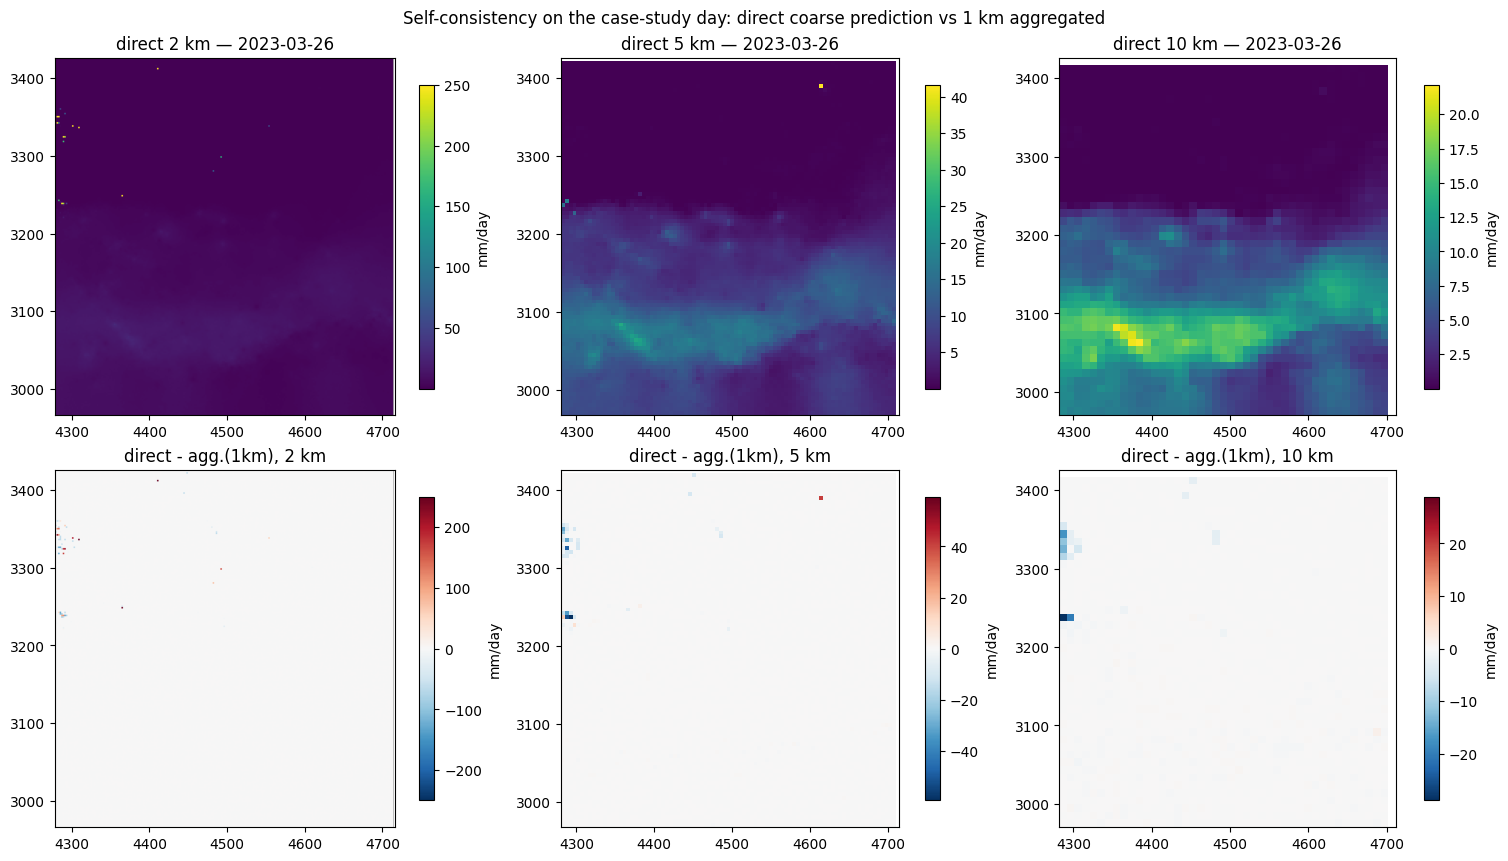

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)
for col, r in enumerate([2, 5, 10]):
    df_r = diff_fields[r]
    day = df_r[df_r['datetime'] == CASE_DATE]
    coarse_grid = preds[r]
    x0, y0, dx, dy = grid_origin_step(coarse_grid)
    xs = np.sort(coarse_grid['x_proj'].unique())
    ys = np.sort(coarse_grid['y_proj'].unique())
    nx, ny = len(xs), len(ys)

    # `day` carries both `x_proj` (original) and `cell_x` (rounded coarse
    # centre); rasterise expects `x_proj`/`y_proj`, so build a slim frame
    # that uses the rounded cell coords as the spatial key.
    day_xy = pd.DataFrame({
        'x_proj':      day['cell_x'].to_numpy(),
        'y_proj':      day['cell_y'].to_numpy(),
        'delta':       day['delta'].to_numpy(),
        'mean_direct': day['mean_direct'].to_numpy(),
    })
    delta_arr  = rasterise(day_xy, x0, y0, dx, dy, nx, ny, column='delta')
    direct_arr = rasterise(day_xy, x0, y0, dx, dy, nx, ny, column='mean_direct')

    ax = axes[0, col]
    im = ax.imshow(direct_arr, origin='lower', cmap='viridis',
                   extent=(xs.min()/1000, xs.max()/1000,
                           ys.min()/1000, ys.max()/1000))
    ax.set_title(f'direct {r} km — {CASE_DATE.date()}')
    plt.colorbar(im, ax=ax, shrink=0.85, label='mm/day')

    vmax = float(np.nanmax(np.abs(delta_arr)))
    ax = axes[1, col]
    im = ax.imshow(delta_arr, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=+vmax,
                   extent=(xs.min()/1000, xs.max()/1000,
                           ys.min()/1000, ys.max()/1000))
    ax.set_title(f'direct - agg.(1km), {r} km')
    plt.colorbar(im, ax=ax, shrink=0.85, label='mm/day')

fig.suptitle('Self-consistency on the case-study day: direct coarse '
             'prediction vs 1 km aggregated')
plt.savefig(FIG_DIR / 'multires_consistency_maps.png', dpi=150)
plt.show()


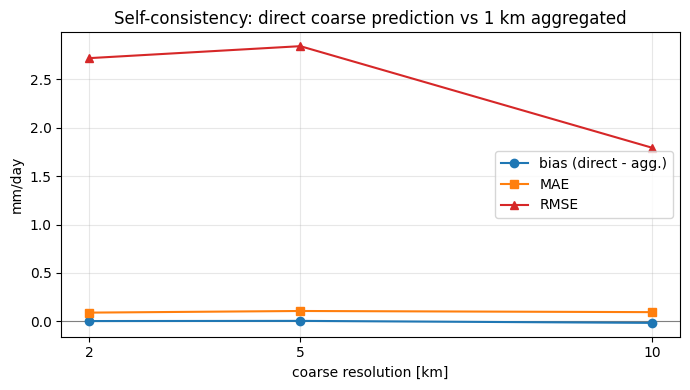

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color='gray', lw=0.8)
ax.plot(consistency_summary.index, consistency_summary['bias_direct_minus_agg'],
        marker='o', color='tab:blue', label='bias (direct - agg.)')
ax.plot(consistency_summary.index, consistency_summary['MAE_direct_vs_agg'],
        marker='s', color='tab:orange', label='MAE')
ax.plot(consistency_summary.index, consistency_summary['RMSE_direct_vs_agg'],
        marker='^', color='tab:red', label='RMSE')
ax.set_xticks(consistency_summary.index)
ax.set_xlabel('coarse resolution [km]')
ax.set_ylabel('mm/day')
ax.set_title('Self-consistency: direct coarse prediction vs 1 km aggregated')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'multires_consistency_summary.png', dpi=150)
plt.show()


## 6. Combined summary

One row per resolution, all three analyses side by side. Saved as
``results/dataset/multires/summary.csv`` for inclusion in the
discussion chapter.


In [11]:
station_part = station_summary.rename(
    columns={'n_pairs': 'n_pairs_station'})
consistency_part = consistency_summary.rename(
    columns={'n_pairs': 'n_pairs_consistency'})

summary = station_part.copy()
summary = summary.join(rough_summary, how='outer')
summary = summary.join(consistency_part, how='outer')
summary = summary.sort_index()
summary.to_csv(OUT_DIR / 'summary.csv')
summary


,n_pairs_station,MAE,RMSE,CRPS,mean_grad_mm_per_km,p95_grad_mm_per_km,mean_field_variance,n_pairs_consistency,bias_direct_minus_agg,MAE_direct_vs_agg,RMSE_direct_vs_agg
resolution_km,,,,,,,,,,,
1,15252,0.294425,0.616489,0.274796,0.145782,0.265565,13.201784,NaN,NaN,NaN,NaN
2,15252,0.299425,0.628686,0.276611,0.100908,0.215128,13.438549,1568259.0,0.001388,0.088491,2.720895
5,15159,0.322010,1.088887,0.281299,0.066980,0.163954,14.049446,248124.0,0.003117,0.105420,2.844618
10,15097,0.337650,0.710137,0.292731,0.044537,0.129219,8.883009,61318.0,-0.017668,0.093464,1.794598
